In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [29]:
cleaned_flights = data[['arrdelay','origin', 'dest', 'uniquecarrier', 'tailnum', 'origincityname']]
cleaned_flights.to_csv("cleaned_flights.csv", index=False)


In [3]:
data=pd.read_csv('DelayData.csv')
data.head()



,depdelay,arrdelay,scheduleddepartdatetime,origin,dest,uniquecarrier,marketshareorigin,marketsharedest,hhiorigin,hhidest,...,windgustdummy,windgustspeed,raindummy,raintracedummy,snowdummy,snowtracedummy,originmetropop,originmetrogdppercapita,destmetropop,destmetrogdppercapita
0,0,-4.0,08-Jan-2004 15:25:00,ELP,SAT,WN,0.618467,0.407567,0.417090,0.226878,...,0,0.0,0,0,0,0,702433,27314.633,1843927,35005.234
1,-4,11.0,22-Jan-2004 14:40:00,ATL,MSY,DL,0.500757,0.096321,0.319589,0.196657,...,0,0.0,0,0,0,0,4802300,49081.773,1314721,48848.234
2,3,12.0,29-Jan-2004 12:25:00,DFW,JFK,DL,0.060898,0.131962,0.296126,0.214357,...,0,0.0,0,0,0,0,5689982,50588.563,18747431,57295.402
3,-3,24.0,14-Jan-2004 15:55:00,SEA,EWR,CO,0.040522,0.347744,0.234712,0.249377,...,0,0.0,1,0,0,0,3163703,57755.547,18747431,57295.402
4,0,-8.0,14-Jan-2004 18:40:00,SLC,RNO,OO,0.506899,0.176493,0.341763,0.277364,...,0,0.0,0,0,0,0,1030597,45043.602,385049,49079.727


In [9]:
# Valeurs distinctes des aéroports de départ
origins = data["origin"].unique()
print("Origines distinctes :", origins)

# Valeurs distinctes des aéroports d'arrivée
destinations = data["dest"].unique()
print("Destinations distinctes :", destinations)


Origines distinctes : ['ELP' 'ATL' 'DFW' 'SEA' 'SLC' 'CVG' 'OAK' 'DEN' 'LAS' 'EWR' 'CLE' 'SMF'
 'ROC' 'PHX' 'DCA' 'IAH' 'IND' 'LGA' 'BWI' 'FNT' 'PSP' 'MRY' 'BZN' 'TPA'
 'SYR' 'MEM' 'CLT' 'RNO' 'PBI' 'STL' 'DAL' 'JFK' 'TUS' 'BOS' 'MCO' 'DTW'
 'MSP' 'SAN' 'HOU' 'JAX' 'MCI' 'PIH' 'BUR' 'MKE' 'ANC' 'MYR' 'AUS' 'SAV'
 'MHT' 'SFO' 'SAT' 'CAK' 'RSW' 'PDX' 'BNA' 'OMA' 'ALB' 'LFT' 'PHL' 'ORD'
 'BUF' 'LAX' 'BRO' 'FAR' 'FCA' 'LBB' 'ORF' 'SDF' 'FLL' 'SNA' 'ISP' 'HRL'
 'PVD' 'MAF' 'BDL' 'ABQ' 'BHM' 'TUL' 'SJC' 'TLH' 'JAN' 'CPR' 'HNL' 'TYS'
 'MDW' 'MIA' 'MSY' 'MFE' 'CRP' 'ICT' 'BIL' 'DAB' 'BTR' 'PIT' 'MDT' 'RAP'
 'GEG' 'DAY' 'OKC' 'SHV' 'IAD' 'MSN' 'GRB' 'ILM' 'PWM' 'BOI' 'RDU' 'AMA'
 'MGM' 'FAT' 'COS' 'PHF' 'PNS' 'RST' 'MBS' 'TYR' 'SBA' 'EGE' 'CAE' 'ABE'
 'AVP' 'HLN' 'XNA' 'GSO' 'LNK' 'CLL' 'CHS' 'MSO' 'GSP' 'HSV' 'SGF' 'RIC'
 'LIT' 'LCH' 'BTV' 'LEX' 'AGS' 'MLI' 'GJT' 'EUG' 'GRR' 'MFR' 'LGB' 'CRW'
 'BIS' 'GGG' 'FAI' 'GTF' 'CHA' 'LAN' 'AVL' 'PSC' 'MLU' 'DSM' 'PIA' 'MLB'
 'IDA' 'MOB' 'FSD' 'TOL' 'EYW

In [223]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1201664 entries, 0 to 1201663
Data columns (total 61 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   depdelay                 1201664 non-null  int64  
 1   arrdelay                 1198458 non-null  float64
 2   scheduleddepartdatetime  1201664 non-null  object 
 3   origin                   1201664 non-null  object 
 4   dest                     1201664 non-null  object 
 5   uniquecarrier            1201664 non-null  object 
 6   marketshareorigin        1201664 non-null  float64
 7   marketsharedest          1201664 non-null  float64
 8   hhiorigin                1201664 non-null  float64
 9   hhidest                  1201664 non-null  float64
 10  nonhubairportorigin      1201664 non-null  int64  
 11  smallhubairportorigin    1201664 non-null  int64  
 12  mediumhubairportorigin   1201664 non-null  int64  
 13  largehubairportorigin    1201664 non-null 

<h3>	Étape 1 : Nettoyage des données </h3>

<h4>Traitement des doublons </h4>

In [11]:
#verifions si on a des valeurs manquantes
data[data.duplicated()]

,depdelay,arrdelay,scheduleddepartdatetime,origin,dest,uniquecarrier,marketshareorigin,marketsharedest,hhiorigin,hhidest,...,windgustdummy,windgustspeed,raindummy,raintracedummy,snowdummy,snowtracedummy,originmetropop,originmetrogdppercapita,destmetropop,destmetrogdppercapita


<h4>Traitement des valeurs manquantes </h4>

In [13]:
colonnes_non_complets=[col for col in data.columns if data[col].isnull().sum()!=0]
colonnes_non_complets

['arrdelay', 'temperature', 'windspeed', 'windspeedsquare', 'windgustspeed']

In [15]:
valeurs_manquantes=data[colonnes_non_complets].isnull().sum()
valeurs_manquantes

arrdelay           3206
temperature         460
windspeed           460
windspeedsquare     460
windgustspeed       460
dtype: int64

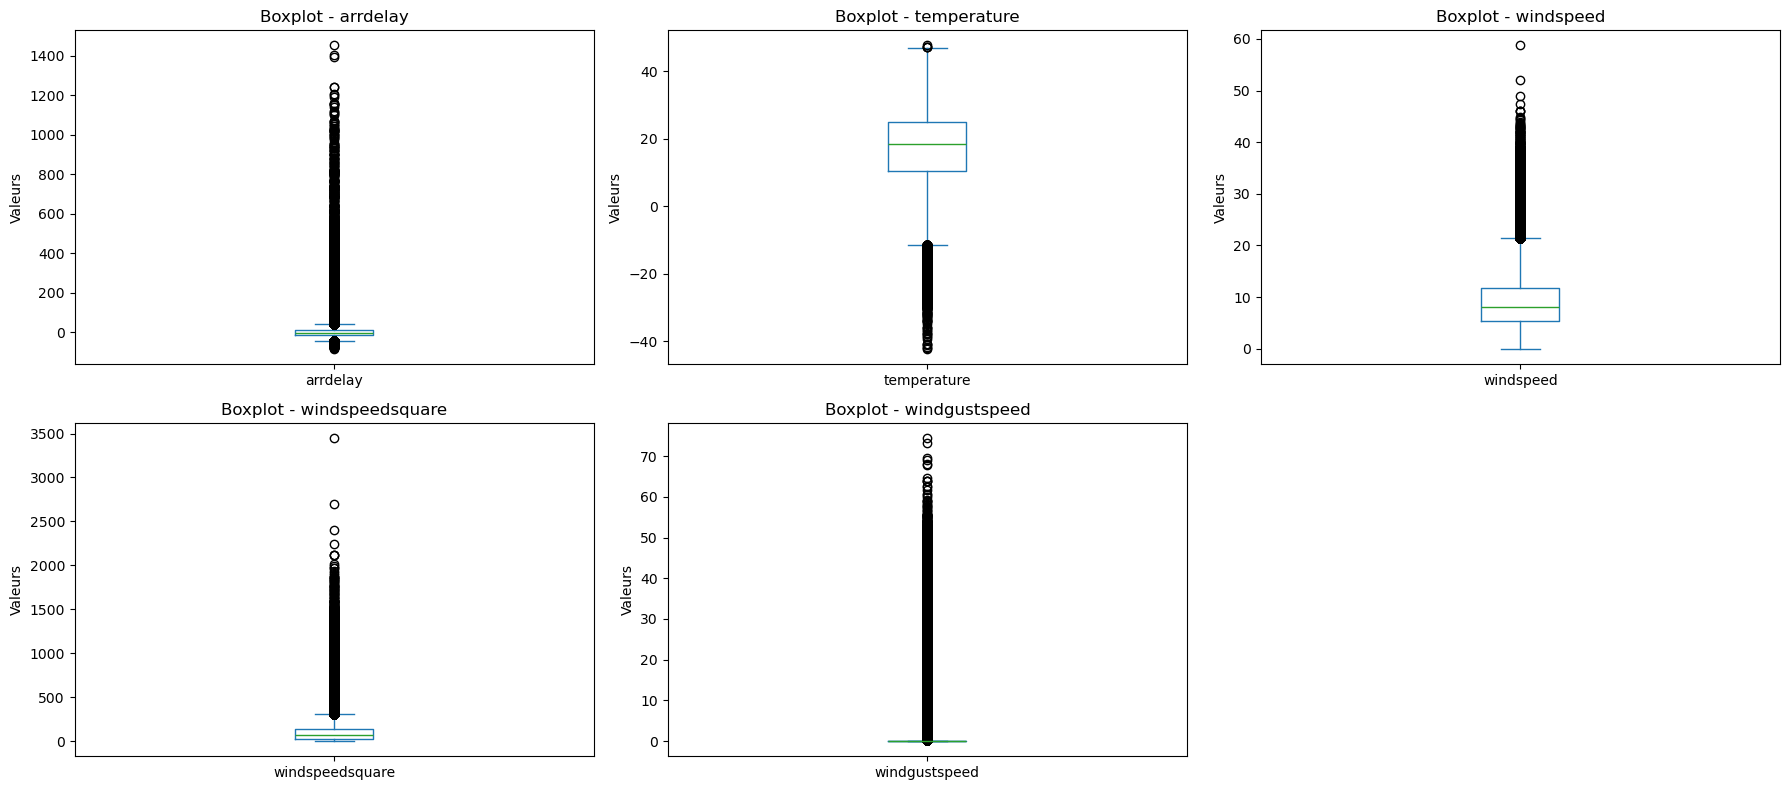

In [17]:
#pour les valeurs manquantes on va les remplir avec la mediane 
# Boxplots pour visualiser les outliers
plt.figure(figsize=(18,8))

for i, col in enumerate(colonnes_non_complets, 1):
    plt.subplot(2, 3, i)
    data[col].dropna().plot(kind='box')
    plt.title(f'Boxplot - {col}')
    plt.ylabel('Valeurs')

plt.tight_layout()
plt.show()

In [19]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='median')

data_imputed=imputer.fit_transform(data[colonnes_non_complets])


In [23]:
data[colonnes_non_complets]=data_imputed

In [25]:
valeurs_manquantes=data[colonnes_non_complets].isnull().sum()
valeurs_manquantes

arrdelay           0
temperature        0
windspeed          0
windspeedsquare    0
windgustspeed      0
dtype: int64

In [231]:
 #maintenant les valeurs manquantes ont été supprimées avec succès

3. Correction des formats incohérents 

In [27]:
data['scheduleddepartdatetime'] = pd.to_datetime(data['scheduleddepartdatetime'])
data[['scheduleddepartdatetime']].dtypes
#conversion en datetime réussie

scheduleddepartdatetime    datetime64[ns]
dtype: object

<h3>Étape 3 : Transformation des données</h3>

1. Encodage

In [24]:
#liste des colonnes catégorielles
data_cat=data.select_dtypes(include="object")
colonnes_categorielles=data_cat.columns
colonnes_categorielles

Index(['origin', 'dest', 'uniquecarrier', 'tailnum', 'origincityname',
       'originstate'],
      dtype='object')

In [26]:
data_cat = data_cat.drop(columns=['originstate'])

In [28]:
#Examinons ces colonnes pour inspecter leur type de données et mieux comprendre leur contenu avant d’appliquer les transformations nécessaires.
data_cat.head()

,origin,dest,uniquecarrier,tailnum,origincityname
0,ELP,SAT,WN,N686,"El Paso, TX"
1,ATL,MSY,DL,N110DL,"Atlanta, GA"
2,DFW,JFK,DL,N933DL,"Dallas/Fort Worth, TX"
3,SEA,EWR,CO,N18243,"Seattle, WA"
4,SLC,RNO,OO,N443SW,"Salt Lake City, UT"


Le Target Encoding est une technique qui transforme une variable catégorielle en un nombre basé sur la moyenne du target (variable cible) pour chaque catégorie.

 On remplace chaque catégorie par la moyenne du target pour cette catégorie.

In [32]:
#!pip install category_encoders

  Using cached category_encoders-2.9.0-py3-none-any.whl.metadata (7.9 kB)
Using cached category_encoders-2.9.0-py3-none-any.whl (85 kB)
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------

In [34]:
#encodage
from category_encoders import TargetEncoder
encoder = TargetEncoder()
target=data['arrdelay']
data_encoded= encoder.fit_transform(data[colonnes_categorielles], target)
data[colonnes_categorielles]=data_encoded

ImportError: cannot import name 'Tags' from 'sklearn.utils' (C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\__init__.py)

In [236]:
#data.info()

3. Ingénierie et extraction de caractéristiques 

L'analyse identifie seize variables binaires organisées en quatre groupes distincts. Le premier ensemble concerne la classification des aéroports d'origine, comprenant les variables nonhubairportorigin ,smallhubairportorigin, mediumhubairportorigin et largehubairportorigin. Le deuxième groupe suit la même logique pour les aéroports de destination avec les variables équivalentes suffixées par 'dest'. Les troisième et quatrième ensemble appliquent cette classification hiérarchique aux compagnies aériennes, distinguant respectivement celles opérant depuis l'origine et celles desservant la destination, selon les quatre niveaux : non-hub, petit hub, hub moyen et grand hub. Cette structure quadruple reflète une segmentation systématique tant géographique qu’opérationnelle du transport aérien.

Plutôt que de conserver 16 variables binaires distinctes, nous allons créer 4 variables catégorielles synthétiques qui capturent l'essentiel de l'information tout en simplifiant significativement le modèle.
Chaque variable regroupera les 4 niveaux hiérarchiques (nonhub(1) → small(2) → medium(3) → large(4)) en une seule feature catégorielle ordonnée, préservant ainsi la relation de taille tout en éliminant la multiplicité des colonnes binaires


In [237]:
data['airport_origin_category']=np.nan #car elle va stocker des valeurs numeriques
data.loc[data['nonhubairportorigin'] == 1, 'airport_origin_category'] = 1
data.loc[data['smallhubairportorigin'] == 1, 'airport_origin_category'] = 2
data.loc[data['mediumhubairportorigin'] == 1, 'airport_origin_category'] = 3
data.loc[data['largehubairportorigin'] == 1, 'airport_origin_category'] = 4

In [238]:
data['airport_dest_category'] = np.nan
data.loc[data['nonhubairportdest'] == 1, 'airport_dest_category'] = 1
data.loc[data['smallhubairportdest'] == 1, 'airport_dest_category'] = 2
data.loc[data['mediumhubairportdest'] == 1, 'airport_dest_category'] = 3
data.loc[data['largehubairportdest'] == 1, 'airport_dest_category'] = 4

In [239]:
data['airline_origin_category'] = np.nan
data.loc[data['nonhubairlineorigin'] == 1, 'airline_origin_category'] =1
data.loc[data['smallhubairlineorigin'] == 1, 'airline_origin_category'] = 2
data.loc[data['mediumhubairlineorigin'] == 1, 'airline_origin_category'] = 3
data.loc[data['largehubairlineorigin'] == 1, 'airline_origin_category'] = 4

In [240]:
data['airline_dest_category'] = np.nan
data.loc[data['nonhubairlinedest'] == 1, 'airline_dest_category'] = 1
data.loc[data['smallhubairlinedest'] == 1, 'airline_dest_category'] = 2
data.loc[data['mediumhubairlinedest'] == 1, 'airline_dest_category'] = 3
data.loc[data['largehubairlinedest'] == 1, 'airline_dest_category'] =4

maintenant on va contatener ces 4 colonnes avec notre dataset et supprimer les anciennes colonnes

In [241]:
# Créer un DataFrame avec les nouvelles colonnes
data_categorie=data[['airport_origin_category','airport_dest_category','airline_dest_category','airline_dest_category']]
#concatenation
data=pd.concat([data,data_categorie],axis=1)

data_categorie.head()
data_categorie.dtypes

airport_origin_category    float64
airport_dest_category      float64
airline_dest_category      float64
airline_dest_category      float64
dtype: object

In [242]:
#supprimer les anciennes colonnes
colonnes_a_supprimer = [
    'nonhubairportorigin', 'smallhubairportorigin', 'mediumhubairportorigin', 'largehubairportorigin',
    'nonhubairportdest', 'smallhubairportdest', 'mediumhubairportdest', 'largehubairportdest',
    'nonhubairlineorigin', 'smallhubairlineorigin', 'mediumhubairlineorigin', 'largehubairlineorigin',
    'nonhubairlinedest', 'smallhubairlinedest', 'mediumhubairlinedest', 'largehubairlinedest'
]

data = data.drop(columns=colonnes_a_supprimer)

In [243]:
#parce qu'on run la cellule a chaque fois les colonnes s'ajoutent aux dataset donc on doit les supprimer
colonnes_dupliquees = data.columns[data.columns.duplicated()].tolist()


#  Supprimer UNIQUEMENT les colonnes dupliquées
data = data.loc[:, ~data.columns.duplicated()]

In [244]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1201664 entries, 0 to 1201663
Data columns (total 49 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   depdelay                 1201664 non-null  int64         
 1   arrdelay                 1201664 non-null  float64       
 2   scheduleddepartdatetime  1201664 non-null  datetime64[ns]
 3   origin                   1201664 non-null  float64       
 4   dest                     1201664 non-null  float64       
 5   uniquecarrier            1201664 non-null  float64       
 6   marketshareorigin        1201664 non-null  float64       
 7   marketsharedest          1201664 non-null  float64       
 8   hhiorigin                1201664 non-null  float64       
 9   hhidest                  1201664 non-null  float64       
 10  year                     1201664 non-null  int64         
 11  month                    1201664 non-null  int64         
 12  

<h5>Simplification des données de température </h5>

Plutôt que de conserver huit variables découpant la température en intervalles, nous avons opté pour une approche plus simple et efficace. La variable continue temperature a été conservée, tandis que les sept variables catégorielles (temp_ninfty_n10, temp_n10_0, etc.) ont été supprimées.

In [245]:
#on va laisser juste temperature
colonnes_temp_supprimer=['temp_ninfty_n10', 'temp_n10_0','temp_0_10', 'temp_10_20', 'temp_20_30', 'temp_30_40', 'temp_40_infty']
data=data.drop(colonnes_temp_supprimer,axis=1)


Pour améliorer la prédiction des retards aériens, nous allons créer deux variables synthétiques capturant les effets temporels significatifs :
 1. Variable is_weekend
    
Objectif : Capturer l'impact différencié des week-ends sur les retards

Logique :

1 pour Samedi (5) et Dimanche (6)

0 pour les jours de semaine (Lundi à Vendredi)


In [246]:
def is_weekend(day):
    #weekend
    if day in [5,6]:
        return True
    else:
        return False
data['is_weekend']=data.apply(lambda x: is_weekend(x['dayofweek']), axis=1)
weekend_impact = data.groupby('is_weekend')['arrdelay'].mean()
print("Impact de weekend :")
print(weekend_impact)

data.columns

Impact de weekend :
is_weekend
False    5.518774
True     5.057870
Name: arrdelay, dtype: float64


Index(['depdelay', 'arrdelay', 'scheduleddepartdatetime', 'origin', 'dest',
       'uniquecarrier', 'marketshareorigin', 'marketsharedest', 'hhiorigin',
       'hhidest', 'year', 'month', 'dayofmonth', 'dayofweek', 'scheduledhour',
       'originairportid', 'destairportid', 'tailnum', 'capacity', 'loadfactor',
       'numflights', 'origincityname', 'originstate', 'distance',
       'monopolyroute', 'temperature', 'windspeed', 'windspeedsquare',
       'windgustdummy', 'windgustspeed', 'raindummy', 'raintracedummy',
       'snowdummy', 'snowtracedummy', 'originmetropop',
       'originmetrogdppercapita', 'destmetropop', 'destmetrogdppercapita',
       'airport_origin_category', 'airport_dest_category',
       'airline_origin_category', 'airline_dest_category', 'is_weekend'],
      dtype='object')

2. Variable is_holiday
Objectif : Identifier les périodes de vacances massives affectant les retards

Périodes ciblées :

Fin décembre (20-31) : Vacances de Noël/Nouvel An

Début janvier (1-3) : Retour de vacances

Été (Juin-Juillet-Août) : Saison estivale chargée

In [247]:
def is_holiday_season(month,day):
    #fin december (20-31)
    if month==12 and day>=17:
        return True
    #debut janvier
    if month==1 and day<=3:
        return True
    #été(summer holiday)
    if month in [6,7,8]:
        return True
    else:
        return False
data['is_holiday_season']=data.apply(lambda x: is_holiday_season(x['month'], x['dayofmonth']), axis=1)
holiday_impact = data.groupby('is_holiday_season')['arrdelay'].mean()
print("Impact période de fêtes :")
print(holiday_impact)

data.columns

Impact période de fêtes :
is_holiday_season
False    3.740622
True     9.038414
Name: arrdelay, dtype: float64


Index(['depdelay', 'arrdelay', 'scheduleddepartdatetime', 'origin', 'dest',
       'uniquecarrier', 'marketshareorigin', 'marketsharedest', 'hhiorigin',
       'hhidest', 'year', 'month', 'dayofmonth', 'dayofweek', 'scheduledhour',
       'originairportid', 'destairportid', 'tailnum', 'capacity', 'loadfactor',
       'numflights', 'origincityname', 'originstate', 'distance',
       'monopolyroute', 'temperature', 'windspeed', 'windspeedsquare',
       'windgustdummy', 'windgustspeed', 'raindummy', 'raintracedummy',
       'snowdummy', 'snowtracedummy', 'originmetropop',
       'originmetrogdppercapita', 'destmetropop', 'destmetrogdppercapita',
       'airport_origin_category', 'airport_dest_category',
       'airline_origin_category', 'airline_dest_category', 'is_weekend',
       'is_holiday_season'],
      dtype='object')

<h4>Étape 4 : Réduction des données</h4>
La réduction des données permet de simplifier l'ensemble des données en réduisant le nombre de caractéristiques ou d'enregistrements tout en préservant les informations essentielles. Cela permet d'accélérer l'analyse et la formation des modèles sans sacrifier la précision.



In [248]:
#correlation

correlations = data.corr()['arrdelay'].sort_values(ascending=False)
correlations

arrdelay                   1.000000
depdelay                   0.932471
scheduledhour              0.124933
raindummy                  0.110754
tailnum                    0.109657
snowdummy                  0.078906
numflights                 0.073779
dest                       0.069055
is_holiday_season          0.065820
origin                     0.059310
windgustdummy              0.058475
windspeed                  0.057042
origincityname             0.056815
uniquecarrier              0.056337
windspeedsquare            0.055680
originstate                0.046109
windgustspeed              0.039851
snowtracedummy             0.037418
raintracedummy             0.032626
destmetropop               0.030132
originmetropop             0.024027
airport_origin_category    0.017967
airline_origin_category    0.017163
dayofmonth                 0.008852
loadfactor                 0.001420
destmetrogdppercapita      0.001235
originmetrogdppercapita    0.000761
temperature               -0

In [249]:
colonnes_a_supprimer = []

for col in data.columns:
      if col != 'arrdelay' :
         correlation = data[col].corr(data['arrdelay'])
         # Vérifier si la corrélation est faible (valeur absolue < 0.056815)
         if abs(correlation) < 0.056:
                colonnes_a_supprimer.append(col)
       

print(colonnes_a_supprimer)
data=data.drop(colonnes_a_supprimer,axis=1)

['scheduleddepartdatetime', 'marketshareorigin', 'marketsharedest', 'hhiorigin', 'hhidest', 'year', 'month', 'dayofmonth', 'dayofweek', 'originairportid', 'destairportid', 'capacity', 'loadfactor', 'originstate', 'distance', 'monopolyroute', 'temperature', 'windspeedsquare', 'windgustspeed', 'raintracedummy', 'snowtracedummy', 'originmetropop', 'originmetrogdppercapita', 'destmetropop', 'destmetrogdppercapita', 'airport_origin_category', 'airport_dest_category', 'airline_origin_category', 'airline_dest_category', 'is_weekend']


In [250]:
data.shape

(1201664, 14)

In [252]:
data.to_csv("data_final.csv", index=False)


In [253]:
data.columns

Index(['depdelay', 'arrdelay', 'origin', 'dest', 'uniquecarrier',
       'scheduledhour', 'tailnum', 'numflights', 'origincityname', 'windspeed',
       'windgustdummy', 'raindummy', 'snowdummy', 'is_holiday_season'],
      dtype='object')

In [255]:
# Analyser la distribution actuelle des retards
retard_count = (data['arrdelay'] >= 15).sum()
non_retard_count = len(data) - retard_count

print(f"Vols en retard : {retard_count} ({retard_count/len(data)*100:.1f}%)")
print(f"Vols à l'heure : {non_retard_count} ({non_retard_count/len(data)*100:.1f}%)")

Vols en retard : 234768 (19.5%)
Vols à l'heure : 966896 (80.5%)


In [257]:
# Taille totale cible (65% du dataset original)
taille_totale_cible = int(len(data) * 0.65)

# Calcul des nombres exacts
n_retard_cible = int(taille_totale_cible * 0.30)    # 30% de retard
n_non_retard_cible = taille_totale_cible - n_retard_cible  # 70% de non-retard

print("📊 CALCUL DES TAILLES CIBLES")
print(f"Dataset original : {len(data):,} vols")
print(f"Taille cible (65%) : {taille_totale_cible:,} vols")
print(f"Retardés cible (30%) : {n_retard_cible:,} vols")
print(f"Non-retardés cible (70%) : {n_non_retard_cible:,} vols")

📊 CALCUL DES TAILLES CIBLES
Dataset original : 1,201,664 vols
Taille cible (65%) : 781,081 vols
Retardés cible (30%) : 234,324 vols
Non-retardés cible (70%) : 546,757 vols


In [258]:
def creer_dataset_30_70(data, taille_totale_cible, ratio_retard=0.30):
    """Crée un dataset avec composition exacte 30% retard / 70% non-retard"""
    
    # Séparer les classes
    data_retard = data[data['arrdelay'] >= 15]
    data_non_retard = data[data['arrdelay'] < 15]
    
    print(f"Données disponibles :")
    print(f"  - Retardés : {len(data_retard):,}")
    print(f"  - Non-retardés : {len(data_non_retard):,}")
    
    # Calculer les nombres exacts
    n_retard_cible = int(taille_totale_cible * ratio_retard)
    n_non_retard_cible = taille_totale_cible - n_retard_cible
    
    print(f"\nComposition cible :")
    print(f"  - Retardés : {n_retard_cible:,} ({ratio_retard*100:.0f}%)")
    print(f"  - Non-retardés : {n_non_retard_cible:,} ({(1-ratio_retard)*100:.0f}%)")
    
    # Vérifier la disponibilité des données
    if n_retard_cible > len(data_retard):
        print(f"⚠️  ATTENTION : Pas assez de vols retardés disponibles")
        print(f"   Disponible : {len(data_retard):,}, Requis : {n_retard_cible:,}")
        n_retard_cible = len(data_retard)
        n_non_retard_cible = taille_totale_cible - n_retard_cible
    
    if n_non_retard_cible > len(data_non_retard):
        print(f"⚠️  ATTENTION : Pas assez de vols non-retardés disponibles")
        print(f"   Disponible : {len(data_non_retard):,}, Requis : {n_non_retard_cible:,}")
        n_non_retard_cible = len(data_non_retard)
        n_retard_cible = taille_totale_cible - n_non_retard_cible
    
    # Échantillonnage
    echantillon_retard = data_retard.sample(n=n_retard_cible, random_state=42)
    echantillon_non_retard = data_non_retard.sample(n=n_non_retard_cible, random_state=42)
    
    # Combiner et mélanger
    dataset_final = pd.concat([echantillon_retard, echantillon_non_retard])
    dataset_final = dataset_final.sample(frac=1, random_state=42)  # Mélanger aléatoirement
    
    return dataset_final

# Application
dataset_30_70 = creer_dataset_30_70(data, taille_totale_cible)

Données disponibles :
  - Retardés : 234,768
  - Non-retardés : 966,896

Composition cible :
  - Retardés : 234,324 (30%)
  - Non-retardés : 546,757 (70%)


In [259]:
# Vérification détaillée
retard_final = (dataset_30_70['arrdelay'] >= 15).sum()
non_retard_final = len(dataset_30_70) - retard_final
ratio_retard_final = retard_final / len(dataset_30_70)
ratio_non_retard_final = non_retard_final / len(dataset_30_70)

print("\n" + "=" * 60)
print("✅ VÉRIFICATION DE LA COMPOSITION FINALE")
print("=" * 60)
print(f"Taille du dataset final : {len(dataset_30_70):,} vols")
print(f"  → Objectif : {taille_totale_cible:,} vols ({len(dataset_30_70)/len(data)*100:.1f}% du original)")
print(f"Vols en retard (≥15min) : {retard_final:,} vols")
print(f"  → Objectif : {n_retard_cible:,} vols ({ratio_retard_final*100:.1f}%)")
print(f"Vols à l'heure (<15min) : {non_retard_final:,} vols")
print(f"  → Objectif : {n_non_retard_cible:,} vols ({ratio_non_retard_final*100:.1f}%)")

# Vérification des écarts
ecart_taille = abs(len(dataset_30_70) - taille_totale_cible) / taille_totale_cible * 100
ecart_ratio = abs(ratio_retard_final - 0.30) * 100

print(f"\n📊 PRÉCISION :")
print(f"  - Écart sur la taille : {ecart_taille:.2f}%")
print(f"  - Écart sur le ratio retard : {ecart_ratio:.2f}%")


✅ VÉRIFICATION DE LA COMPOSITION FINALE
Taille du dataset final : 781,081 vols
  → Objectif : 781,081 vols (65.0% du original)
Vols en retard (≥15min) : 234,324 vols
  → Objectif : 234,324 vols (30.0%)
Vols à l'heure (<15min) : 546,757 vols
  → Objectif : 546,757 vols (70.0%)

📊 PRÉCISION :
  - Écart sur la taille : 0.00%
  - Écart sur le ratio retard : 0.00%


In [260]:
dataset_30_70.shape

(781081, 15)

In [261]:
dataset_30_70.to_csv("data_final_promax.csv", index=False)


In [262]:
import joblib

joblib.dump(encoder, "target_encoder.pkl")

['target_encoder.pkl']